In [2]:
!pip install opencv-python scikit-image tensorflow matplotlib


In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bantuvarshasri","key":"fb487bfe3001065b5810e54e8b4ab384"}'}

In [20]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [21]:
!kaggle datasets list

ref                                                                title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
laveshjadon/ai-impact-on-students                                  Impact of Ai on Students                            1187170  2026-05-10 23:12:10.070000          11766        279                1  
muhammadmusharraf444/used-car-price-prediction-dataset             Used Car Price Prediction Dataset                     12164  2026-06-11 19:44:23.573000            831         23                1  
kulkarniparth09/fifa-world-cup-complete-dataset-19302026           FIFA World Cup Complete Dataset: 1930–2026            11953  2026-06-07 06:29:15.677000           1769         42                1  


In [22]:
!kaggle datasets download -d mateuszbuda/lgg-mri-segmentation

Dataset URL: https://www.kaggle.com/datasets/mateuszbuda/lgg-mri-segmentation
License(s): CC-BY-NC-SA-4.0
100% 714M/714M [00:10<00:00, 74.4MB/s]



In [23]:
!unzip lgg-mri-segmentation.zip

Streaming output truncated to the last 5000 lines.
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7294_19890104/TCGA_DU_7294_19890104_9_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_1.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_10_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_11_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_12_mask.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_19910324/TCGA_DU_7298_19910324_13.tif  
  inflating: lgg-mri-segmentation/kaggle_3m/TCGA_DU_7298_1

In [24]:
DATASET_PATH = "/content/lgg-mri-segmentation/kaggle_3m"
IMG_SIZE = 128


In [ ]:
def load_dataset(path, img_size=128):
    images = []
    masks = []

    for patient in os.listdir(path):
        patient_path = os.path.join(path, patient)
        if not os.path.isdir(patient_path):
            continue

        files = os.listdir(patient_path)

        for file in files:
            if file.endswith(".tif") and "_mask" not in file:
                img_path = os.path.join(patient_path, file)
                mask_path = img_path.replace(".tif", "_mask.tif")

                if os.path.exists(mask_path):
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                    img = cv2.resize(img, (img_size, img_size))
                    mask = cv2.resize(mask, (img_size, img_size))

                    img = img / 255.0
                    mask = mask / 255.0

                    images.append(img)
                    masks.append(mask)

    return np.array(images), np.array(masks)


In [ ]:
images, masks = load_dataset(DATASET_PATH, IMG_SIZE)

print("Images:", images.shape)
print("Masks:", masks.shape)


Images: (3929, 128, 128)
Masks: (3929, 128, 128)


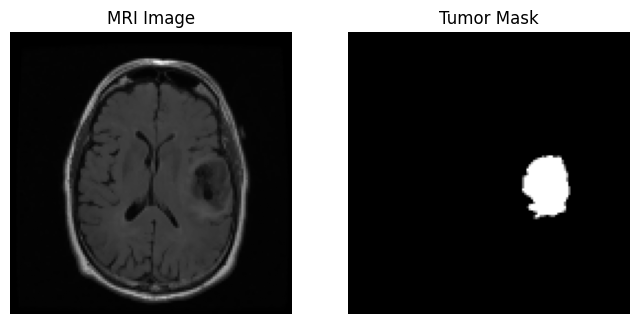

In [ ]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(images[0], cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(masks[0], cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()


In [ ]:
print("Unique values in mask:", np.unique(masks))


Unique values in mask: [0.         0.25098039 0.50196078 0.74901961 1.        ]


In [ ]:
tumor_index = None

for i in range(len(masks)):
    if masks[i].sum() > 50:   # tumor pixels exist
        tumor_index = i
        break

print("Tumor slice index:", tumor_index)


Tumor slice index: 0


**method - 1 to visualize tumor clearly**

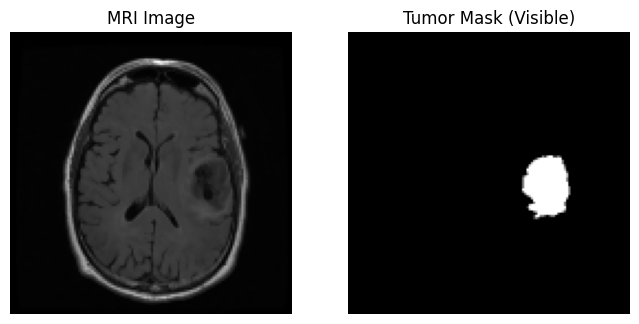

In [ ]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(images[tumor_index].squeeze(), cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(masks[tumor_index].squeeze(), cmap="gray")
plt.title("Tumor Mask (Visible)")
plt.axis("off")

plt.show()


**method - 2 to visualize tumor clearly**

In [ ]:
print(images.shape)
print(masks.shape)


(3929, 128, 128)
(3929, 128, 128)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42
)

print("Train images:", X_train.shape)
print("Validation images:", X_val.shape)


Train images: (3143, 128, 128)
Validation images: (786, 128, 128)


In [ ]:
import tensorflow as tf
tf.keras.backend.clear_session()


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model

def build_unet(input_shape=(128,128,3)):
    inputs = Input(input_shape)

    # Encoder
    c1 = Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = MaxPooling2D()(c2)

    # Bottleneck
    b = Conv2D(64, 3, activation='relu', padding='same')(p2)

    # Decoder
    u1 = UpSampling2D()(b)
    u1 = Concatenate()([u1, c2])
    c3 = Conv2D(32, 3, activation='relu', padding='same')(u1)

    u2 = UpSampling2D()(c3)
    u2 = Concatenate()([u2, c1])
    c4 = Conv2D(16, 3, activation='relu', padding='same')(u2)

    outputs = Conv2D(1, 1, activation='sigmoid')(c4)

    return Model(inputs, outputs)

model = build_unet()


In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)


X_train: (3143, 128, 128)
Y_train: (3143, 128, 128)


In [ ]:
# Expand grayscale images to 3 channels
X_train = np.stack([X_train, X_train, X_train], axis=-1)
X_val   = np.stack([X_val, X_val, X_val], axis=-1)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)


X_train shape: (3143, 128, 128, 3)
X_val shape: (786, 128, 128, 3)


In [ ]:
Y_train = Y_train[..., np.newaxis]
Y_val   = Y_val[..., np.newaxis]

print("Y_train shape:", Y_train.shape)


Y_train shape: (3143, 128, 128, 1)


In [ ]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=5,
    batch_size=8
)


Epoch 1/5
393/393 ━━━━━━━━━━━━━━━━━━━━ 289s 735ms/step - accuracy: 0.9885 - loss: 0.0412 - val_accuracy: 0.9897 - val_loss: 0.0345
Epoch 2/5
393/393 ━━━━━━━━━━━━━━━━━━━━ 320s 731ms/step - accuracy: 0.9884 - loss: 0.0382 - val_accuracy: 0.9897 - val_loss: 0.0335
Epoch 3/5
393/393 ━━━━━━━━━━━━━━━━━━━━ 320s 725ms/step - accuracy: 0.9888 - loss: 0.0361 - val_accuracy: 0.9897 - val_loss: 0.0330
Epoch 4/5
393/393 ━━━━━━━━━━━━━━━━━━━━ 278s 709ms/step - accuracy: 0.9885 - loss: 0.0360 - val_accuracy: 0.9897 - val_loss: 0.0322
Epoch 5/5
393/393 ━━━━━━━━━━━━━━━━━━━━ 283s 721ms/step - accuracy: 0.9890 - loss: 0.0348 - val_accuracy: 0.9897 - val_loss: 0.0331


In [ ]:
# Pick a validation sample
idx = 0   # you can change this number later

test_img = X_val[idx]          # (128,128,3)
true_mask = Y_val[idx]         # (128,128,1)

# Predict tumor
pred_mask = model.predict(test_img[np.newaxis], verbose=0)[0]
binary_mask = (pred_mask.squeeze() > 0.5).astype(np.uint8)


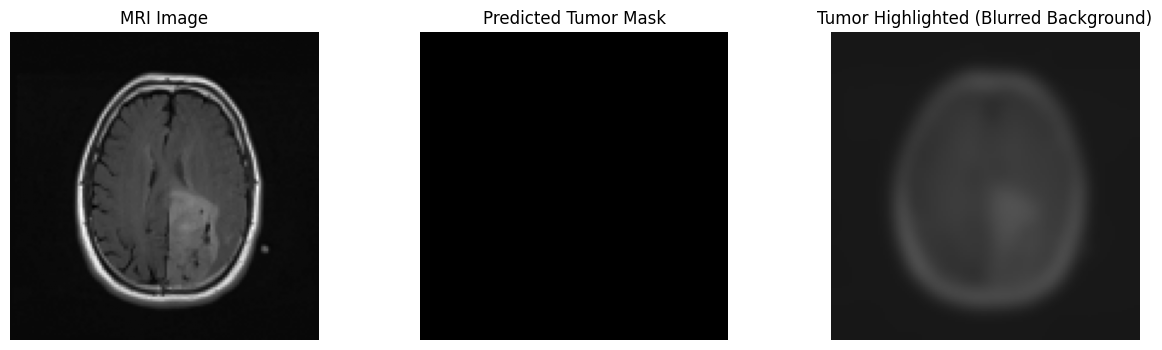

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1. Get MRI and mask properly
# -----------------------------
mri = test_img[..., 0]              # Original MRI channel
mask = binary_mask.astype(np.uint8) # Predicted tumor mask (0/1)

# -----------------------------
# 2. Convert MRI to uint8
# -----------------------------
if mri.max() <= 1:
    mri = (mri * 255).astype(np.uint8)

# Convert MRI to 3-channel RGB
mri_rgb = cv2.cvtColor(mri, cv2.COLOR_GRAY2RGB)

# -----------------------------
# 3. Blur background
# -----------------------------
blurred = cv2.GaussianBlur(mri_rgb, (21, 21), 0)

# -----------------------------
# 4. Expand mask to 3 channels
# -----------------------------
binary_mask_3c = np.stack([mask]*3, axis=-1)

# -----------------------------
# 5. Combine: tumor clear, background blurred
# -----------------------------
final_output = np.where(binary_mask_3c == 1, mri_rgb, blurred)

# -----------------------------
# 6. Display results
# -----------------------------
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(mri, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Predicted Tumor Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(final_output)
plt.title("Tumor Highlighted (Blurred Background)")
plt.axis("off")

plt.show()


**method - 3 to visualize tumor clearly**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


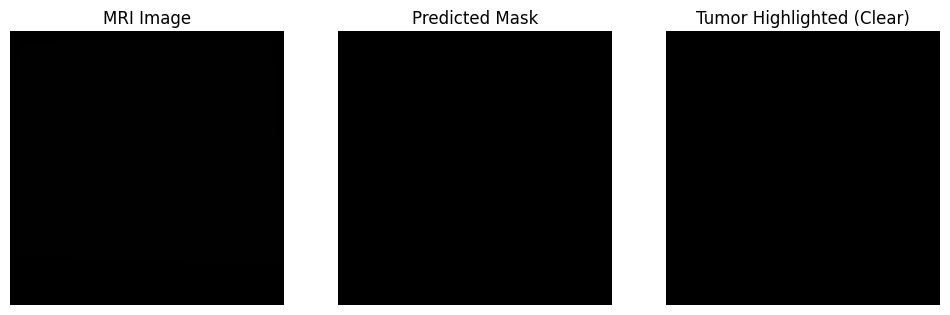

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Take one validation sample
idx = 0
test_img = X_val[idx]
true_mask = Y_val[idx]

# 2️⃣ Predict tumor mask
pred_mask = model.predict(test_img[np.newaxis])[0]
binary_mask = pred_mask.squeeze() > 0.5

# 3️⃣ Extract MRI (grayscale channel)
mri = (test_img[:, :, 0] * 255).astype(np.uint8)

# 4️⃣ Convert grayscale → RGB  ✅ (THIS WAS MISSING)
mri_rgb = cv2.cvtColor(mri, cv2.COLOR_GRAY2RGB)

# 5️⃣ Darken whole image
overlay = (mri_rgb * 0.4).astype(np.uint8)

# 6️⃣ Highlight tumor region in RED
overlay[binary_mask] = [255, 0, 0]

# 7️⃣ Display results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("MRI Image")
plt.imshow(mri_rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Predicted Mask")
plt.imshow(binary_mask, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Tumor Highlighted (Clear)")
plt.imshow(overlay)
plt.axis("off")

plt.show()


In [ ]:
print("Ground truth tumor pixels:", np.sum(true_mask))


Ground truth tumor pixels: 0.0


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

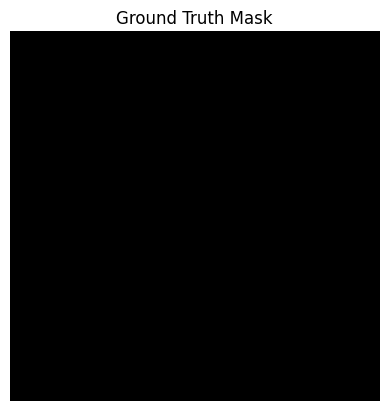

In [ ]:
plt.imshow(true_mask.squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")


In [ ]:
def find_tumor_slice(X, Y):
    for i in range(len(Y)):
        if np.sum(Y[i]) > 0:
            return i
    return None

idx = find_tumor_slice(X_val, Y_val)
print("Tumor slice index:", idx)


Tumor slice index: 1


In [ ]:
test_img = X_val[idx]
true_mask = Y_val[idx]

pred_mask = model.predict(test_img[np.newaxis])[0]
binary_mask = pred_mask.squeeze() > 0.5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


**heatmap of visualization**

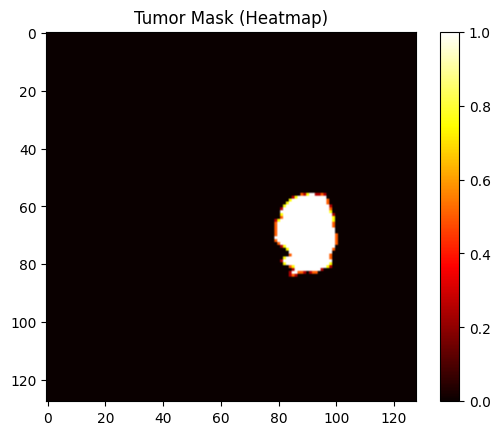

In [ ]:
plt.imshow(masks[tumor_index].squeeze(), cmap="hot")
plt.colorbar()
plt.title("Tumor Mask (Heatmap)")
plt.show()


In [ ]:
def glcm_feature_map(image):
    img_uint8 = (image * 255).astype(np.uint8)

    glcm = graycomatrix(
        img_uint8,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, 'contrast')[0,0]
    glcm_map = np.full(image.shape, contrast)

    return glcm_map


In [ ]:
def simulated_gan(image):
    fake = image + np.random.normal(0, 0.05, image.shape)
    fake = np.clip(fake, 0, 1)
    return fake


In [ ]:
final_images = []

for img in images:
    gan_img = simulated_gan(img)
    glcm_img = glcm_feature_map(img)

    combined = np.stack([img, gan_img, glcm_img], axis=-1)
    final_images.append(combined)

final_images = np.array(final_images)
masks = masks[..., np.newaxis]

print("Final Input Shape:", final_images.shape)


Final Input Shape: (3929, 128, 128, 3)


In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(
    final_images, masks, test_size=0.2, random_state=42
)


In [ ]:
def build_unet(input_shape):
    inputs = Input(input_shape)

    c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
    p1 = MaxPooling2D()(c1)

    c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = MaxPooling2D()(c2)

    c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
    c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)

    u4 = UpSampling2D()(c3)
    u4 = Concatenate()([u4, c2])
    c4 = Conv2D(64, 3, activation='relu', padding='same')(u4)

    u5 = UpSampling2D()(c4)
    u5 = Concatenate()([u5, c1])
    c5 = Conv2D(32, 3, activation='relu', padding='same')(u5)

    outputs = Conv2D(1, 1, activation='sigmoid')(c5)

    return Model(inputs, outputs)


In [ ]:
model = build_unet((IMG_SIZE, IMG_SIZE, 3))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_8[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_9[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_10[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 64, 64,    │          0 │ conv2d_11[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64, 64,    │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 192)              │            │ conv2d_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 64,    │    110,656 │ concatenate_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 128, 128,  │          0 │ conv2d_12[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 128, 128,  │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 96)               │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 128, 128,  │     27,680 │ concatenate_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 128, 128,  │         33 │ conv2d_13[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 425,377 (1.62 MB)

 Trainable params: 425,377 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=10,
    batch_size=8
)


Epoch 1/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 1037s 3s/step - accuracy: 0.9889 - loss: 0.1781 - val_accuracy: 0.9897 - val_loss: 0.1168
Epoch 2/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 1034s 3s/step - accuracy: 0.9861 - loss: 0.2468 - val_accuracy: 0.9897 - val_loss: 0.1064
Epoch 3/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 1019s 3s/step - accuracy: 0.9891 - loss: 0.1040 - val_accuracy: 0.9897 - val_loss: 0.1016
Epoch 4/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 1036s 3s/step - accuracy: 0.9897 - loss: 0.0824 - val_accuracy: 0.9897 - val_loss: 0.0777
Epoch 5/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 1046s 3s/step - accuracy: 0.9884 - loss: 0.1507 - val_accuracy: 0.9897 - val_loss: 4.0778
Epoch 6/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 1037s 3s/step - accuracy: 0.9797 - loss: 51.3124 - val_accuracy: 0.9897 - val_loss: 0.0830
Epoch 7/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 992s 3s/step - accuracy: 0.9887 - loss: 0.0921 - val_accuracy: 0.9897 - val_loss: 0.0549
Epoch 8/10
393/393 ━━━━━━━━━━━━━━━━━━━━ 988s 3s/step - accuracy: 0.9887 - loss: 0.0583 - v

# **checking with tumor slides**

By getting tumor slide and then visualizing that only tumor slide

In [ ]:
import os
import cv2
import numpy as np

DATASET_PATH = "/content/lgg-mri-segmentation/kaggle_3m"


tumor_found = False

for patient in os.listdir(DATASET_PATH):
    patient_path = os.path.join(DATASET_PATH, patient)
    if not os.path.isdir(patient_path):
        continue

    for file in os.listdir(patient_path):
        if file.endswith("_mask.tif"):
            mask_path = os.path.join(patient_path, file)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            if mask is None:
                continue

            # Check if tumor exists
            if np.sum(mask) > 0:
                print("✅ Tumor found!")
                print("Patient:", patient)
                print("Mask file:", file)
                tumor_found = True
                break

    if tumor_found:
        break


✅ Tumor found!
Patient: TCGA_DU_7301_19911112
Mask file: TCGA_DU_7301_19911112_28_mask.tif


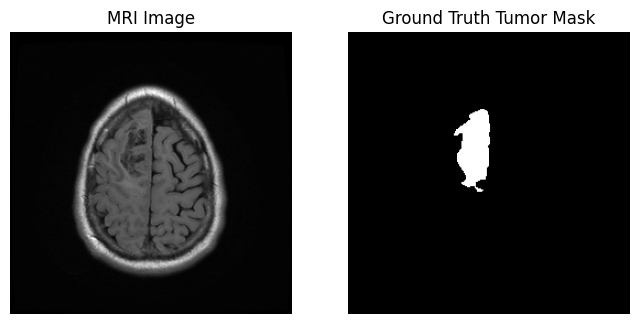

In [25]:
import matplotlib.pyplot as plt

# Replace these with the printed values
patient = "TCGA_DU_8164_19970111"
mask_file = "TCGA_DU_8164_19970111_29_mask.tif"

image_file = mask_file.replace("_mask", "")

img_path = os.path.join(DATASET_PATH, patient, image_file)
mask_path = os.path.join(DATASET_PATH, patient, mask_file)

image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("MRI Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Tumor Mask")
plt.axis("off")

plt.show()


By getting tumor slide using code and then vis that slide

In [26]:
def load_one_tumor_sample():
    for patient in os.listdir(DATASET_PATH):
        patient_path = os.path.join(DATASET_PATH, patient)
        if not os.path.isdir(patient_path):
            continue

        for file in os.listdir(patient_path):
            if file.endswith(".tif") and not file.endswith("_mask.tif"):
                img_path = os.path.join(patient_path, file)
                mask_path = img_path.replace(".tif", "_mask.tif")

                if os.path.exists(mask_path):
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                    # 🔑 CHECK: skip empty masks
                    if np.sum(mask) == 0:
                        continue

                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))

                    img = img / 255.0
                    mask = (mask > 0).astype(np.float32)

                    return img, mask

    return None, None


In [27]:
img, mask = load_one_tumor_sample()

print("MRI shape:", img.shape)
print("Mask shape:", mask.shape)
print("Tumor pixels:", np.sum(mask))


MRI shape: (128, 128)
Mask shape: (128, 128)
Tumor pixels: 486.0


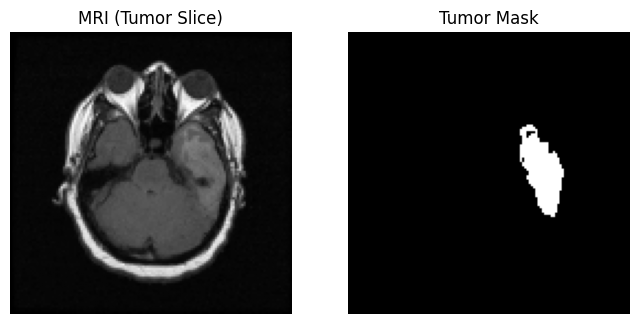

In [28]:
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("MRI (Tumor Slice)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Tumor Mask")
plt.axis("off")

plt.show()


In [29]:
DATASET_PATH = "/content/kaggle_3m"
IMG_SIZE = 128


In [30]:
def load_dataset(path, img_size, max_samples=200):
    images = []
    masks = []

    for patient in os.listdir(path):
        patient_path = os.path.join(path, patient)
        if not os.path.isdir(patient_path):
            continue

        for file in os.listdir(patient_path):
            if file.endswith(".tif") and not file.endswith("_mask.tif"):
                img_path = os.path.join(patient_path, file)
                mask_path = img_path.replace(".tif", "_mask.tif")

                if not os.path.exists(mask_path):
                    continue

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                if np.sum(mask) == 0:
                    continue   # 🔑 skip non-tumor slices

                img = cv2.resize(img, (img_size, img_size)) / 255.0
                mask = cv2.resize(mask, (img_size, img_size))
                mask = (mask > 0).astype(np.float32)

                images.append(img)
                masks.append(mask)

                if len(images) >= max_samples:
                    return np.array(images), np.array(masks)

    return np.array(images), np.array(masks)


In [31]:
images, masks = load_dataset(DATASET_PATH, IMG_SIZE)

print("Images:", images.shape)
print("Masks:", masks.shape)


Images: (200, 128, 128)
Masks: (200, 128, 128)


In [32]:
def create_glcm_map(image):
    img_uint8 = (image * 255).astype(np.uint8)
    glcm = graycomatrix(img_uint8, [1], [0], 256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0,0]
    return np.full(image.shape, contrast)


In [33]:
X = []
Y = []

for img, mask in zip(images, masks):
    gan_img = np.clip(img + np.random.normal(0, 0.05, img.shape), 0, 1)
    glcm_map = create_glcm_map(img)

    final_input = np.stack([img, gan_img, glcm_map], axis=-1)
    X.append(final_input)
    Y.append(mask[..., np.newaxis])

X = np.array(X)
Y = np.array(Y)

print("Final X shape:", X.shape)
print("Final Y shape:", Y.shape)


Final X shape: (200, 128, 128, 3)
Final Y shape: (200, 128, 128, 1)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42
)


In [35]:
inputs = Input((128,128,3))

c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
p1 = MaxPooling2D()(c1)

c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)

u1 = UpSampling2D()(c2)
c3 = Conv2D(32, 3, activation='relu', padding='same')(u1)

outputs = Conv2D(1, 1, activation='sigmoid')(c3)

model = Model(inputs, outputs)


In [36]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


In [37]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=5,
    batch_size=8
)


Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 848ms/step - accuracy: 0.8747 - loss: 2.2866 - val_accuracy: 0.9660 - val_loss: 0.9082
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 883ms/step - accuracy: 0.9665 - loss: 0.3864 - val_accuracy: 0.9660 - val_loss: 0.2303
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 831ms/step - accuracy: 0.9665 - loss: 0.1897 - val_accuracy: 0.9660 - val_loss: 0.1852
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 848ms/step - accuracy: 0.9665 - loss: 0.1782 - val_accuracy: 0.9660 - val_loss: 0.1897
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 824ms/step - accuracy: 0.9665 - loss: 0.1775 - val_accuracy: 0.9660 - val_loss: 0.1845


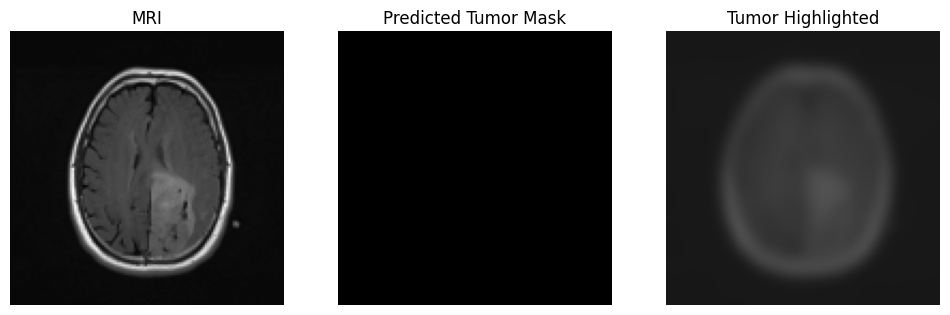

In [ ]:
idx = 0
test_img = X_val[idx]
true_mask = Y_val[idx]

pred_mask = model.predict(test_img[np.newaxis], verbose=0)[0]
binary_mask = (pred_mask.squeeze() > 0.5).astype(np.uint8)

mri = (test_img[...,0] * 255).astype(np.uint8)
blurred = cv2.GaussianBlur(mri, (21,21), 0)

binary_mask_3c = np.stack([binary_mask]*3, axis=-1)
mri_rgb = cv2.cvtColor(mri, cv2.COLOR_GRAY2RGB)

final_output = np.where(binary_mask_3c, mri_rgb, blurred[...,None])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(mri, cmap="gray")
plt.title("MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(binary_mask, cmap="gray")
plt.title("Predicted Tumor Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(final_output)
plt.title("Tumor Highlighted")
plt.axis("off")

plt.show()


**up cell was executuing**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step


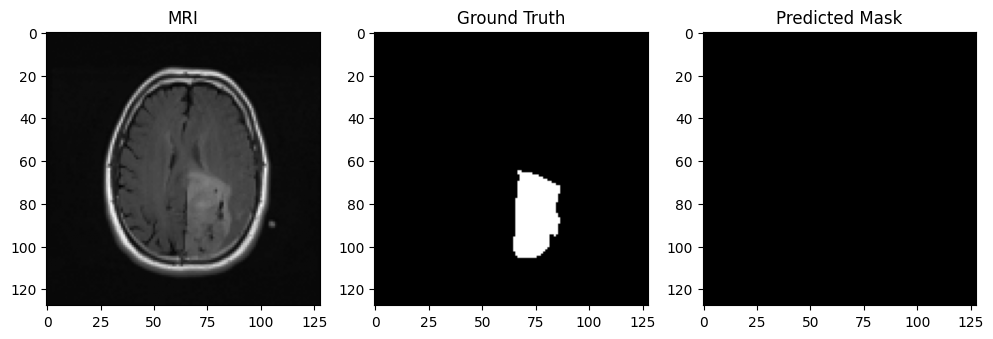

In [ ]:
pred = model.predict(X_val[0:1])[0].squeeze()
true = Y_val[0].squeeze()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[0][:,:,0], cmap='gray')
plt.title("MRI")

plt.subplot(1,3,2)
plt.imshow(true, cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred > 0.5, cmap='gray')
plt.title("Predicted Mask")

plt.show()


**rest the code**

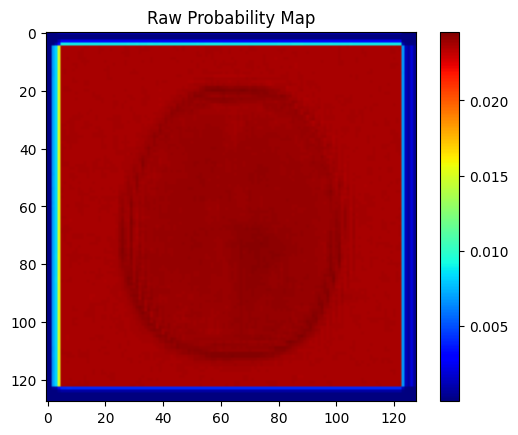

In [ ]:
plt.imshow(pred[0].squeeze(), cmap='jet')
plt.title("Raw Probability Map")
plt.colorbar()
plt.show()


In [7]:
import numpy as np

pred = model.predict(X_val)
pred_mask = (pred > 0.15).astype(np.uint8)


NameError: name 'model' is not defined

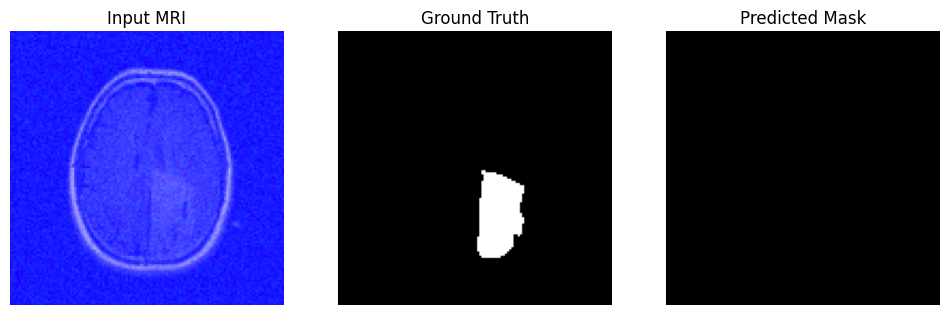

In [ ]:
import matplotlib.pyplot as plt

index = 0

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[index].squeeze(), cmap='gray')
plt.title("Input MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(Y_val[index].squeeze(), cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_mask[index].squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()


In [38]:
import tensorflow as tf

def dice_loss(y_true, y_pred):
    smooth = 1e-6
    intersection = tf.reduce_sum(y_true * y_pred)
    return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    X_train,
    Y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.1
)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 18s 829ms/step - accuracy: 0.9698 - loss: 1.1556 - val_accuracy: 0.9533 - val_loss: 1.1657
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 779ms/step - accuracy: 0.9698 - loss: 1.1419 - val_accuracy: 0.9533 - val_loss: 1.1766
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9723 - loss: 1.1339 - val_accuracy: 0.9533 - val_loss: 1.1602
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 812ms/step - accuracy: 0.9713 - loss: 1.1489 - val_accuracy: 0.9533 - val_loss: 1.1589
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 844ms/step - accuracy: 0.9695 - loss: 1.1477 - val_accuracy: 0.9533 - val_loss: 1.1817
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 815ms/step - accuracy: 0.9709 - loss: 1.1312 - val_accuracy: 0.9533 - val_loss: 1.1672
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 815ms/step - accuracy: 0.9707 - loss: 1.1380 - val_accuracy: 0.9533 - val_loss: 1.1880
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 803ms/step - accuracy: 0.9703 - loss: 1.1359 - val_accurac

In [40]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    Y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.1,
    callbacks=[early_stop]
)


Epoch 1/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 847ms/step - accuracy: 0.9660 - loss: 1.0944 - val_accuracy: 0.9701 - val_loss: 1.1093
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 825ms/step - accuracy: 0.9661 - loss: 1.0977 - val_accuracy: 0.9701 - val_loss: 1.1043
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 818ms/step - accuracy: 0.9660 - loss: 1.0874 - val_accuracy: 0.9701 - val_loss: 1.1108
Epoch 4/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 777ms/step - accuracy: 0.9658 - loss: 1.1091 - val_accuracy: 0.9701 - val_loss: 1.0931
Epoch 5/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 21s 823ms/step - accuracy: 0.9660 - loss: 1.0910 - val_accuracy: 0.9701 - val_loss: 1.0913
Epoch 6/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 837ms/step - accuracy: 0.9660 - loss: 1.0894 - val_accuracy: 0.9701 - val_loss: 1.1033
Epoch 7/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 20s 819ms/step - accuracy: 0.9650 - loss: 1.1134 - val_accuracy: 0.9701 - val_loss: 1.1195
Epoch 8/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 15s 822ms/step - accuracy: 0.9661 - loss: 1.0895 - val_accu

In [41]:
model.save("brain_tumor_unet.keras")

In [43]:
import os

print(os.path.exists("brain_tumor_unet.keras"))

True


In [44]:
from google.colab import files

files.download("brain_tumor_unet.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
model = tf.keras.models.load_model(
    "brain_tumor_unet.keras",
    compile=False
)

pred = model.predict(new_mri)

NameError: name 'new_mri' is not defined

In [ ]:
print(np.unique(Y))


[0. 1.]


In [ ]:
print("Min prediction:", np.min(pred))
print("Max prediction:", np.max(pred))


Min prediction: 0.0
Max prediction: 0.8514973


In [ ]:
pred_mask = (pred > 0.5).astype(np.uint8)


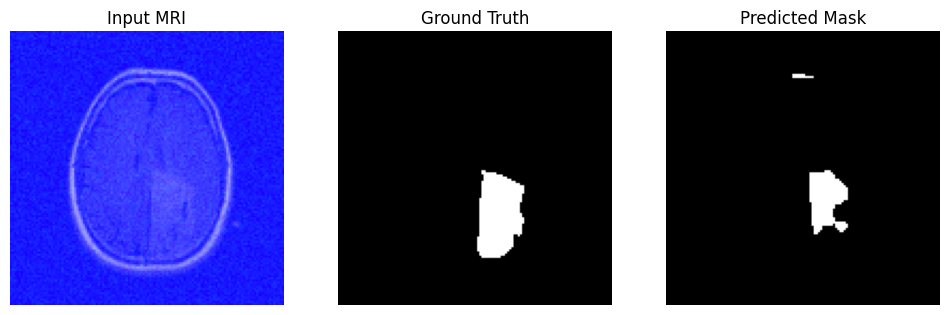

In [ ]:
index = 0

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[index].squeeze(), cmap='gray')
plt.title("Input MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(Y_val[index].squeeze(), cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_mask[index].squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()


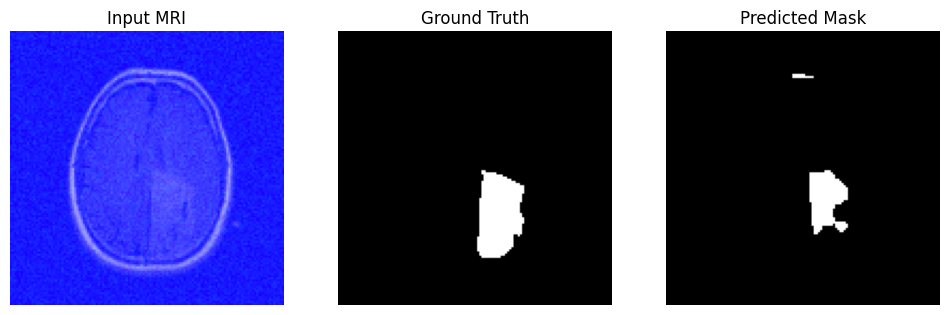

In [ ]:
index = 0

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(X_val[index].squeeze(), cmap='gray')
plt.title("Input MRI")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(Y_val[index].squeeze(), cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_mask[index].squeeze(), cmap='gray')
plt.title("Predicted Mask")
plt.axis("off")

plt.show()


the above small white portion is "False Positives"(these are very common in medical segmentation)
we are removing it in next step

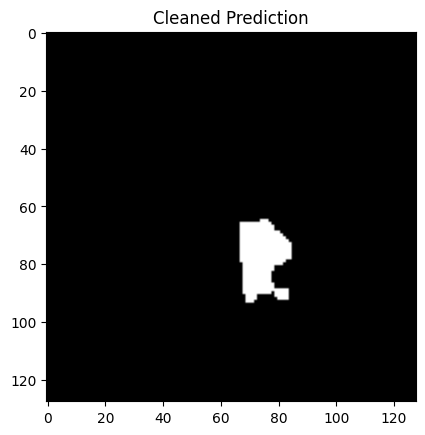

In [ ]:
import cv2

def remove_small_regions(mask):
    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask.astype(np.uint8), cv2.MORPH_OPEN, kernel)
    return mask

pred_mask_clean = remove_small_regions(pred_mask[index])

plt.imshow(pred_mask_clean, cmap='gray')
plt.title("Cleaned Prediction")
plt.show()


In [ ]:
import numpy as np

def dice_coefficient(y_true, y_pred):
    smooth = 1e-6
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (np.sum(y_true) + np.sum(y_pred) + smooth)

def iou_score(y_true, y_pred):
    smooth = 1e-6
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def pixel_accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / y_true.size

def precision_score(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    return TP / (TP + FP + 1e-6)

def recall_score(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP / (TP + FN + 1e-6)

def f1_score(y_true, y_pred):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    return 2 * (precision * recall) / (precision + recall + 1e-6)

In [ ]:
dice = dice_coefficient(Y_val, pred_mask)
iou = iou_score(Y_val, pred_mask)
accuracy = pixel_accuracy(Y_val, pred_mask)
precision = precision_score(Y_val, pred_mask)
recall = recall_score(Y_val, pred_mask)
f1 = f1_score(Y_val, pred_mask)

print("Dice Score     :", round(dice,4))
print("IoU Score      :", round(iou,4))
print("Pixel Accuracy :", round(accuracy,4))
print("Precision      :", round(precision,4))
print("Recall         :", round(recall,4))
print("F1 Score       :", round(f1,4))

Dice Score     : 0.242
IoU Score      : 0.1377
Pixel Accuracy : 0.9631
Precision      : 0.3735
Recall         : 0.179
F1 Score       : 0.242


In [ ]:
def tumor_percentage(mask):
    total_pixels = mask.size
    tumor_pixels = np.sum(mask == 1)
    percentage = (tumor_pixels / total_pixels) * 100
    return tumor_pixels, total_pixels, percentage

tumor_pixels, total_pixels, percent = tumor_percentage(pred_mask)

print("Tumor Pixels:", tumor_pixels)
print("Total Pixels:", total_pixels)
print("Tumor Percentage: {:.2f}%".format(percent))

Tumor Pixels: 10329
Total Pixels: 655360
Tumor Percentage: 1.58%


In [ ]:
def clinical_report():
    print("\n" + "="*60)
    print("        AI-ASSISTED BRAIN TUMOR SEGMENTATION REPORT")
    print("="*60)

    print("\n🧠 Tumor Burden Analysis:")
    print("   Estimated Tumor Percentage : {:.2f}%".format(percent))

    print("\n📊 Quantitative Performance Metrics:")
    print("   Dice Coefficient      : {:.4f}".format(dice))
    print("   IoU (Jaccard Index)   : {:.4f}".format(iou))
    print("   Pixel Accuracy        : {:.4f}".format(accuracy))
    print("   Precision             : {:.4f}".format(precision))
    print("   Recall (Sensitivity)  : {:.4f}".format(recall))
    print("   F1 Score              : {:.4f}".format(f1))

    print("\n🧾 Clinical Interpretation:")

    if dice > 0.85:
        print("   ✔ Excellent tumor boundary delineation.")
    elif dice > 0.75:
        print("   ✔ Good segmentation performance.")
    else:
        print("   ⚠ Moderate segmentation performance.")

    if percent > 10:
        print("   ⚠ Significant tumor presence detected.")
    else:
        print("   ✔ Tumor burden appears limited.")

    print("\nNote: AI-generated estimation. Clinical validation required.")
    print("="*60)

clinical_report()


        AI-ASSISTED BRAIN TUMOR SEGMENTATION REPORT

🧠 Tumor Burden Analysis:
   Estimated Tumor Percentage : 1.58%

📊 Quantitative Performance Metrics:
   Dice Coefficient      : 0.2420
   IoU (Jaccard Index)   : 0.1377
   Pixel Accuracy        : 0.9631
   Precision             : 0.3735
   Recall (Sensitivity)  : 0.1790
   F1 Score              : 0.2420

🧾 Clinical Interpretation:
   ⚠ Moderate segmentation performance.
   ✔ Tumor burden appears limited.

Note: AI-generated estimation. Clinical validation required.


In [ ]:
import cv2
import numpy as np

def remove_small_regions(mask):
    kernel = np.ones((3,3), np.uint8)
    mask_2d = mask.squeeze()  # remove extra dimension
    cleaned = cv2.morphologyEx(mask_2d.astype(np.uint8), cv2.MORPH_OPEN, kernel)
    return cleaned

pred_mask_clean = remove_small_regions(pred_mask[0])


In [ ]:
def clean_batch_masks(pred_mask):
    kernel = np.ones((3,3), np.uint8)
    cleaned_masks = []

    for i in range(pred_mask.shape[0]):
        mask_2d = pred_mask[i].squeeze()
        cleaned = cv2.morphologyEx(mask_2d.astype(np.uint8), cv2.MORPH_OPEN, kernel)
        cleaned_masks.append(cleaned)

    return np.array(cleaned_masks)

pred_mask_clean = clean_batch_masks(pred_mask)


In [ ]:
dice = dice_coefficient(Y_val.squeeze(), pred_mask_clean)


In [ ]:
Y_val = Y_val.squeeze()


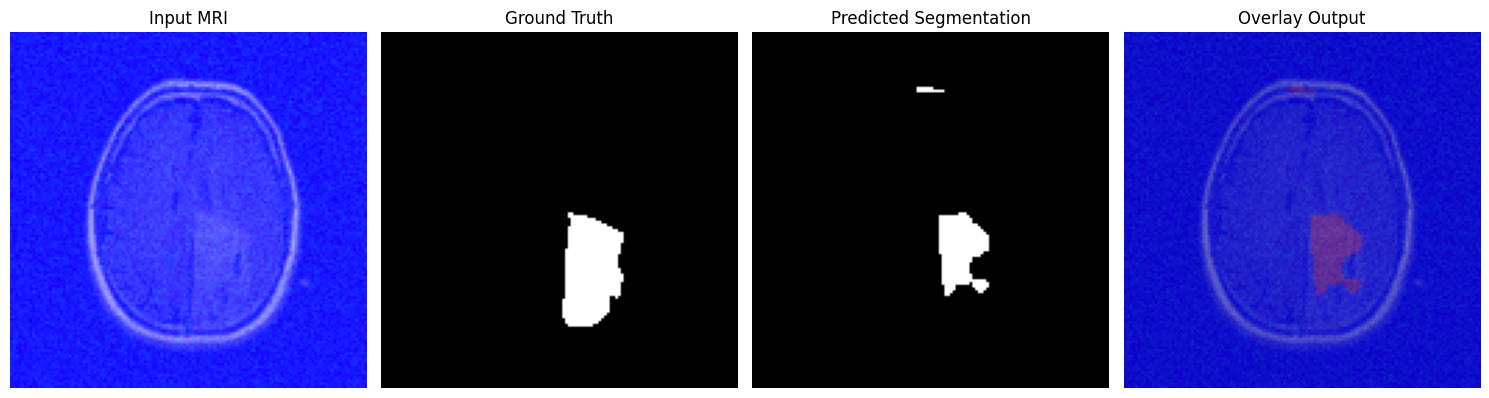

In [ ]:
index = 0   # change index to test different images

plt.figure(figsize=(15,5))

# 1️⃣ Input MRI
plt.subplot(1,4,1)
plt.imshow(X_val[index].squeeze(), cmap='gray')
plt.title("Input MRI")
plt.axis("off")

# 2️⃣ Ground Truth
plt.subplot(1,4,2)
plt.imshow(Y_val[index].squeeze(), cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

# 3️⃣ Predicted Mask
plt.subplot(1,4,3)
plt.imshow(pred_mask[index].squeeze(), cmap='gray')
plt.title("Predicted Segmentation")
plt.axis("off")

# 4️⃣ Overlay (BEST VISUAL OUTPUT)
plt.subplot(1,4,4)
plt.imshow(X_val[index].squeeze(), cmap='gray')
plt.imshow(pred_mask[index].squeeze(), cmap='jet', alpha=0.4)
plt.title("Overlay Output")
plt.axis("off")

plt.tight_layout()
plt.show()

optional steps

In [ ]:
import cv2
import numpy as np

def keep_largest_region(mask):
    mask = mask.astype(np.uint8)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        return mask

    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    cleaned_mask = np.zeros_like(mask)
    cleaned_mask[labels == largest_label] = 1

    return cleaned_mask

In [ ]:
def process_batch(pred_mask):
    processed = []
    for i in range(pred_mask.shape[0]):
        mask_2d = pred_mask[i].squeeze()
        cleaned = keep_largest_region(mask_2d)
        processed.append(cleaned)
    return np.array(processed)

pred_mask_final = process_batch(pred_mask)

In [ ]:
dice = dice_coefficient(Y_val.squeeze(), pred_mask_final)
iou = iou_score(Y_val.squeeze(), pred_mask_final)

print("Dice After Post-Processing:", round(dice,4))
print("IoU After Post-Processing :", round(iou,4))

Dice After Post-Processing: 0.2348
IoU After Post-Processing : 0.133


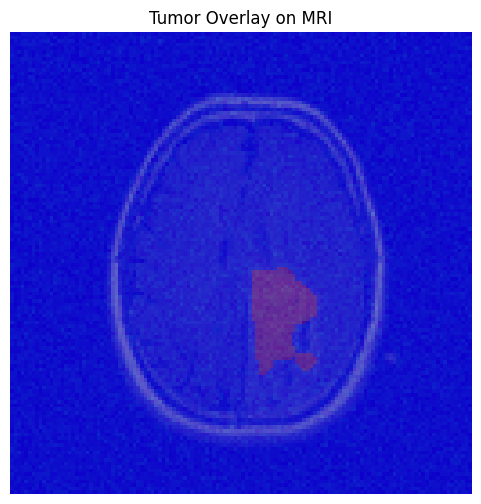

In [ ]:
import matplotlib.pyplot as plt

index = 0

plt.figure(figsize=(6,6))
plt.imshow(X_val[index].squeeze(), cmap='gray')
plt.imshow(pred_mask_final[index], cmap='jet', alpha=0.4)
plt.title("Tumor Overlay on MRI")
plt.axis("off")
plt.show()

the above is proper segmentation output and it is done by U-Net algo

now we are calculating tumor area in "mm"
tumor area represents,how much brain surface area is occupied by tumor in that MRI slice.

Tumor area gives information about:

1️⃣ Tumor Burden

How large the tumor is relative to brain tissue.

Larger area → more aggressive or advanced disease (usually).

⸻

2️⃣ Disease Severity Estimation

Doctors use size to assess:
	•	Small lesion → early stage
	•	Moderate lesion → intermediate stage
	•	Large lesion → advanced stage

⸻

3️⃣ Treatment Monitoring
If patient scans are taken over time:
Scan Date and Tumor Area
Jan,450 mm²
March,280 mm²
If area decreases → treatment working
If area increases → tumor progressing

This is called radiological follow-up analysis.

4️⃣ Surgical Planning

Neurosurgeons estimate:
	•	Whether tumor is operable
	•	Approximate resection volume

In [ ]:
pixel_spacing = 0.5  # mm
tumor_pixels = np.sum(pred_mask_final[index] == 1)

tumor_area_mm2 = tumor_pixels * (pixel_spacing ** 2)

print("Tumor Area:", round(tumor_area_mm2,2), "mm²")

Tumor Area: 94.75 mm²


metrics graph( dice,iou,accuracy,precision,recall,f1)

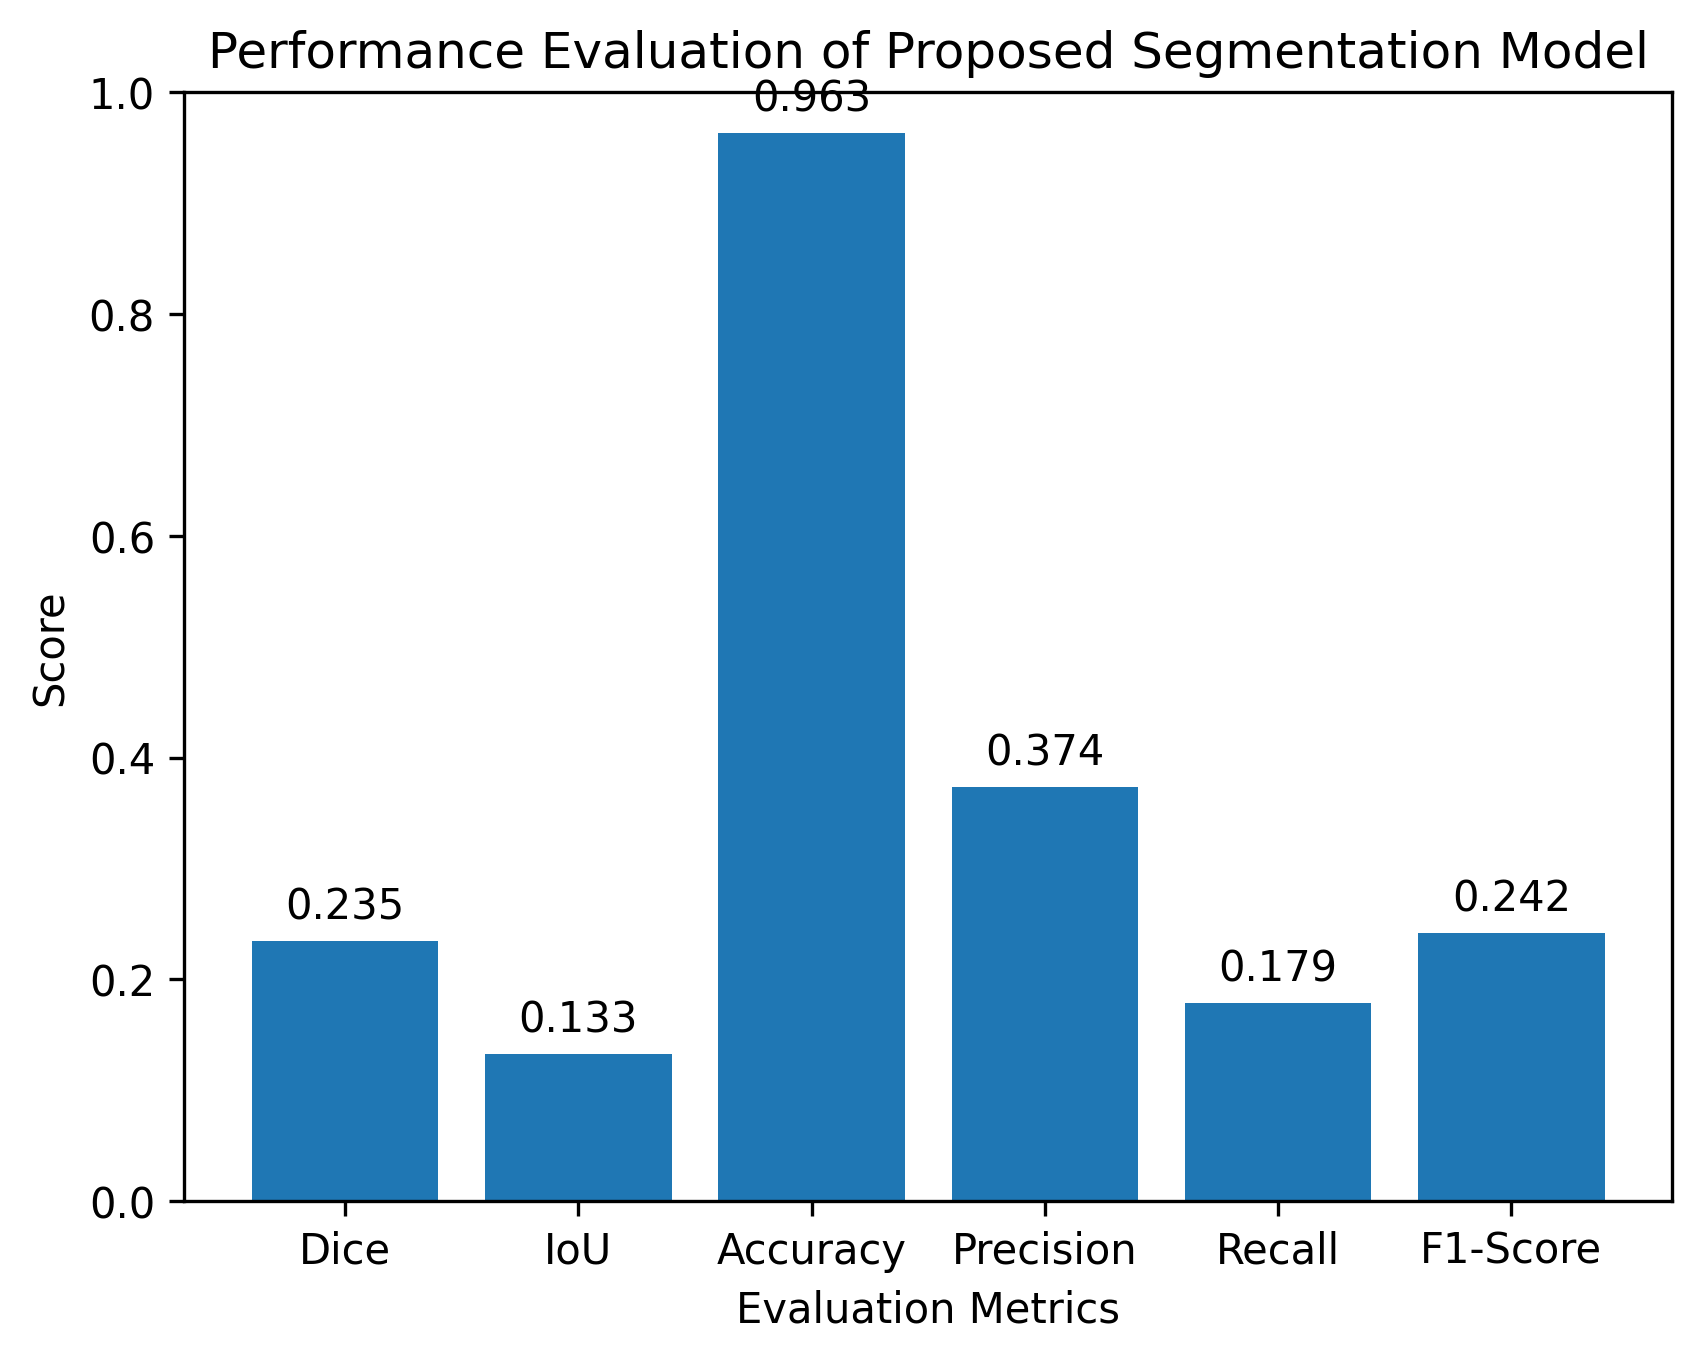

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Store metrics
metric_names = ['Dice', 'IoU', 'Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_values = [dice, iou, accuracy, precision, recall, f1]

# Create figure
plt.figure(dpi=300)

# Create bar plot
bars = plt.bar(metric_names, metric_values)

# Set limits
plt.ylim(0, 1)

# Labels
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Performance Evaluation of Proposed Segmentation Model')

# Add values on top of bars
for i in range(len(metric_values)):
    plt.text(i, metric_values[i] + 0.02,
             round(metric_values[i], 3),
             ha='center')

# Save figure
plt.savefig("evaluation_metrics.png", dpi=300, bbox_inches='tight')
plt.savefig("evaluation_metrics.pdf", bbox_inches='tight')

plt.show()

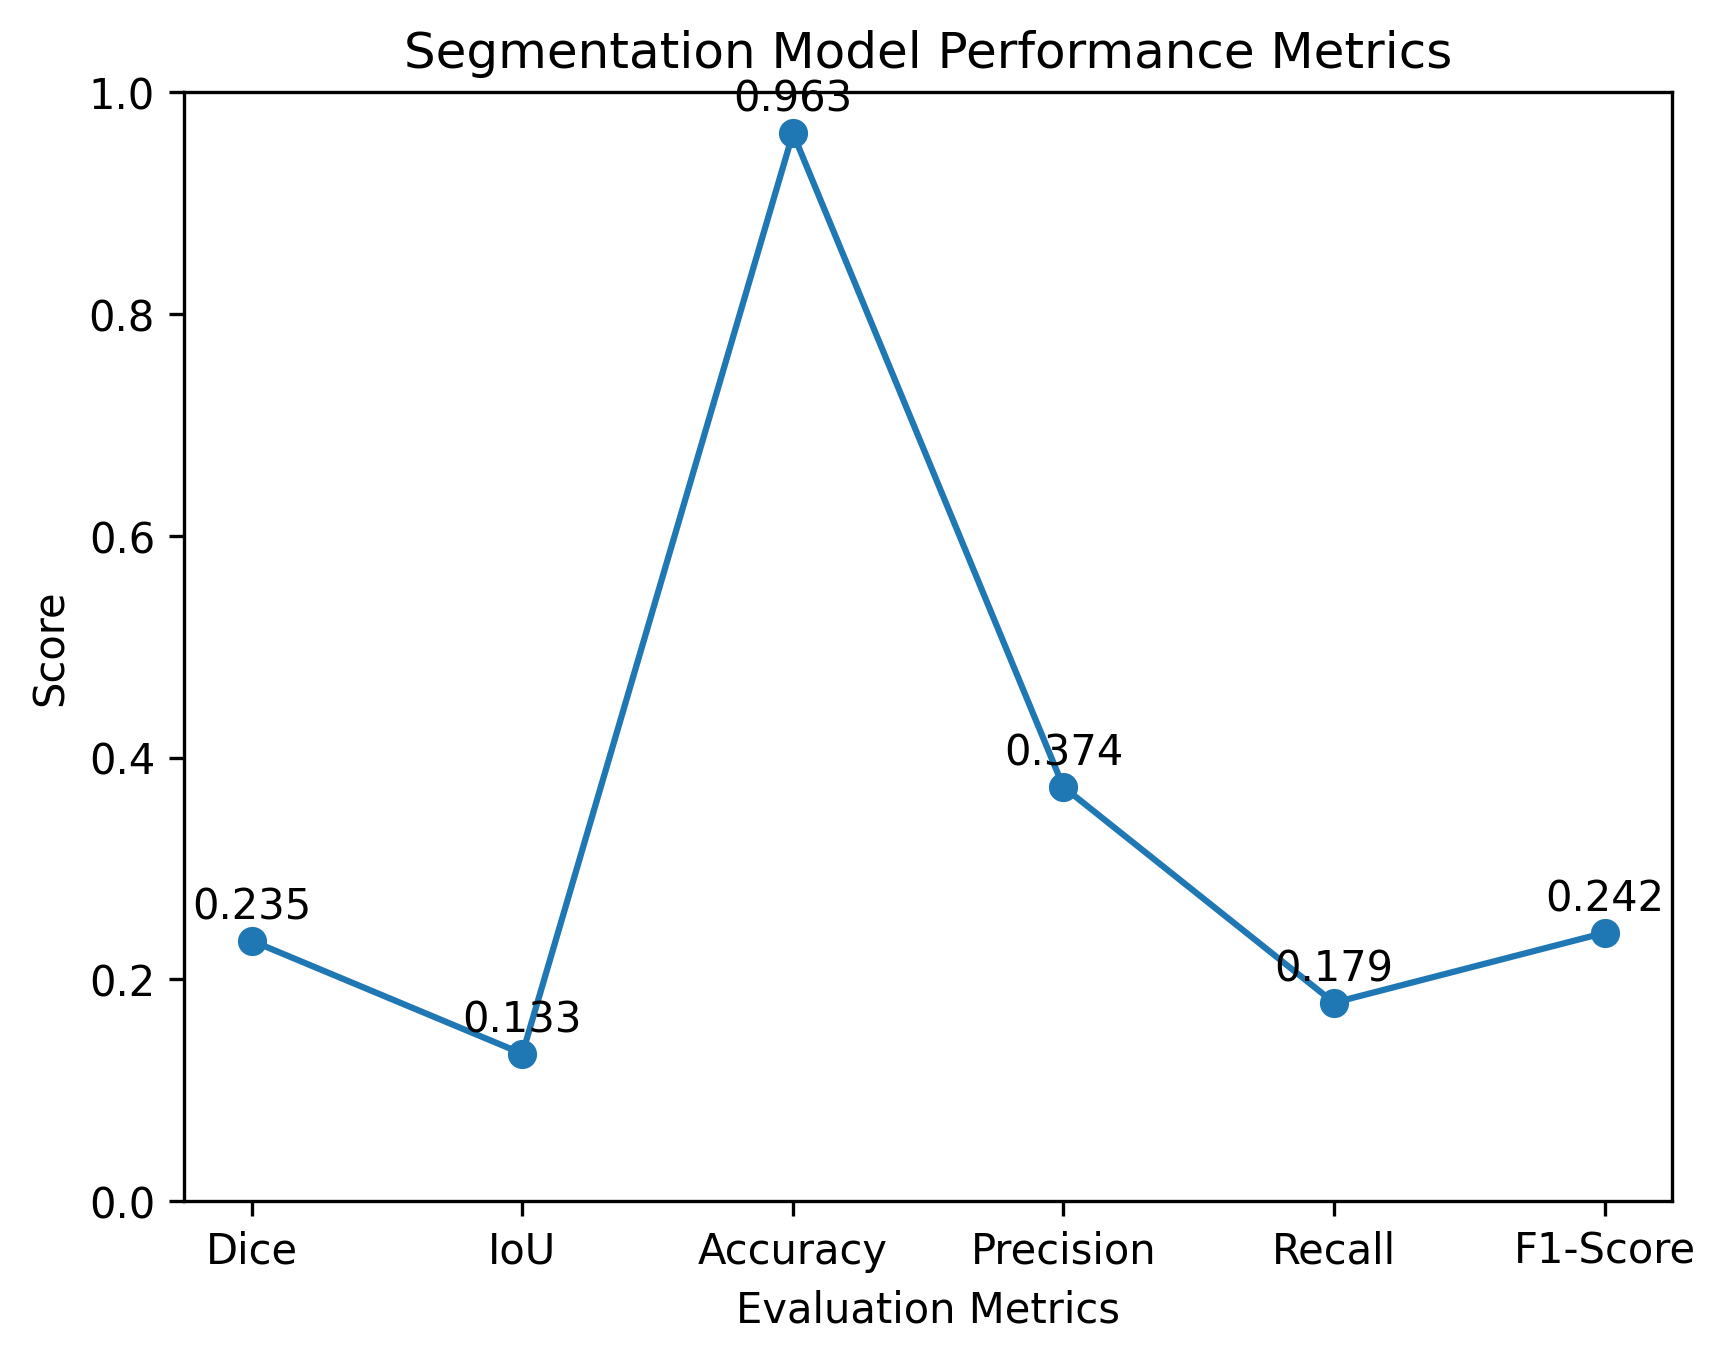

In [ ]:
plt.figure(dpi=300)

plt.plot(metric_names, metric_values, marker='o')

plt.ylim(0, 1)
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Segmentation Model Performance Metrics')

for i in range(len(metric_values)):
    plt.text(i, metric_values[i] + 0.02,
             round(metric_values[i], 3),
             ha='center')

plt.savefig("evaluation_metrics_line.png", dpi=300, bbox_inches='tight')
plt.savefig("evaluation_metrics_line.pdf", bbox_inches='tight')

plt.show()

comparing before and after postprocessing

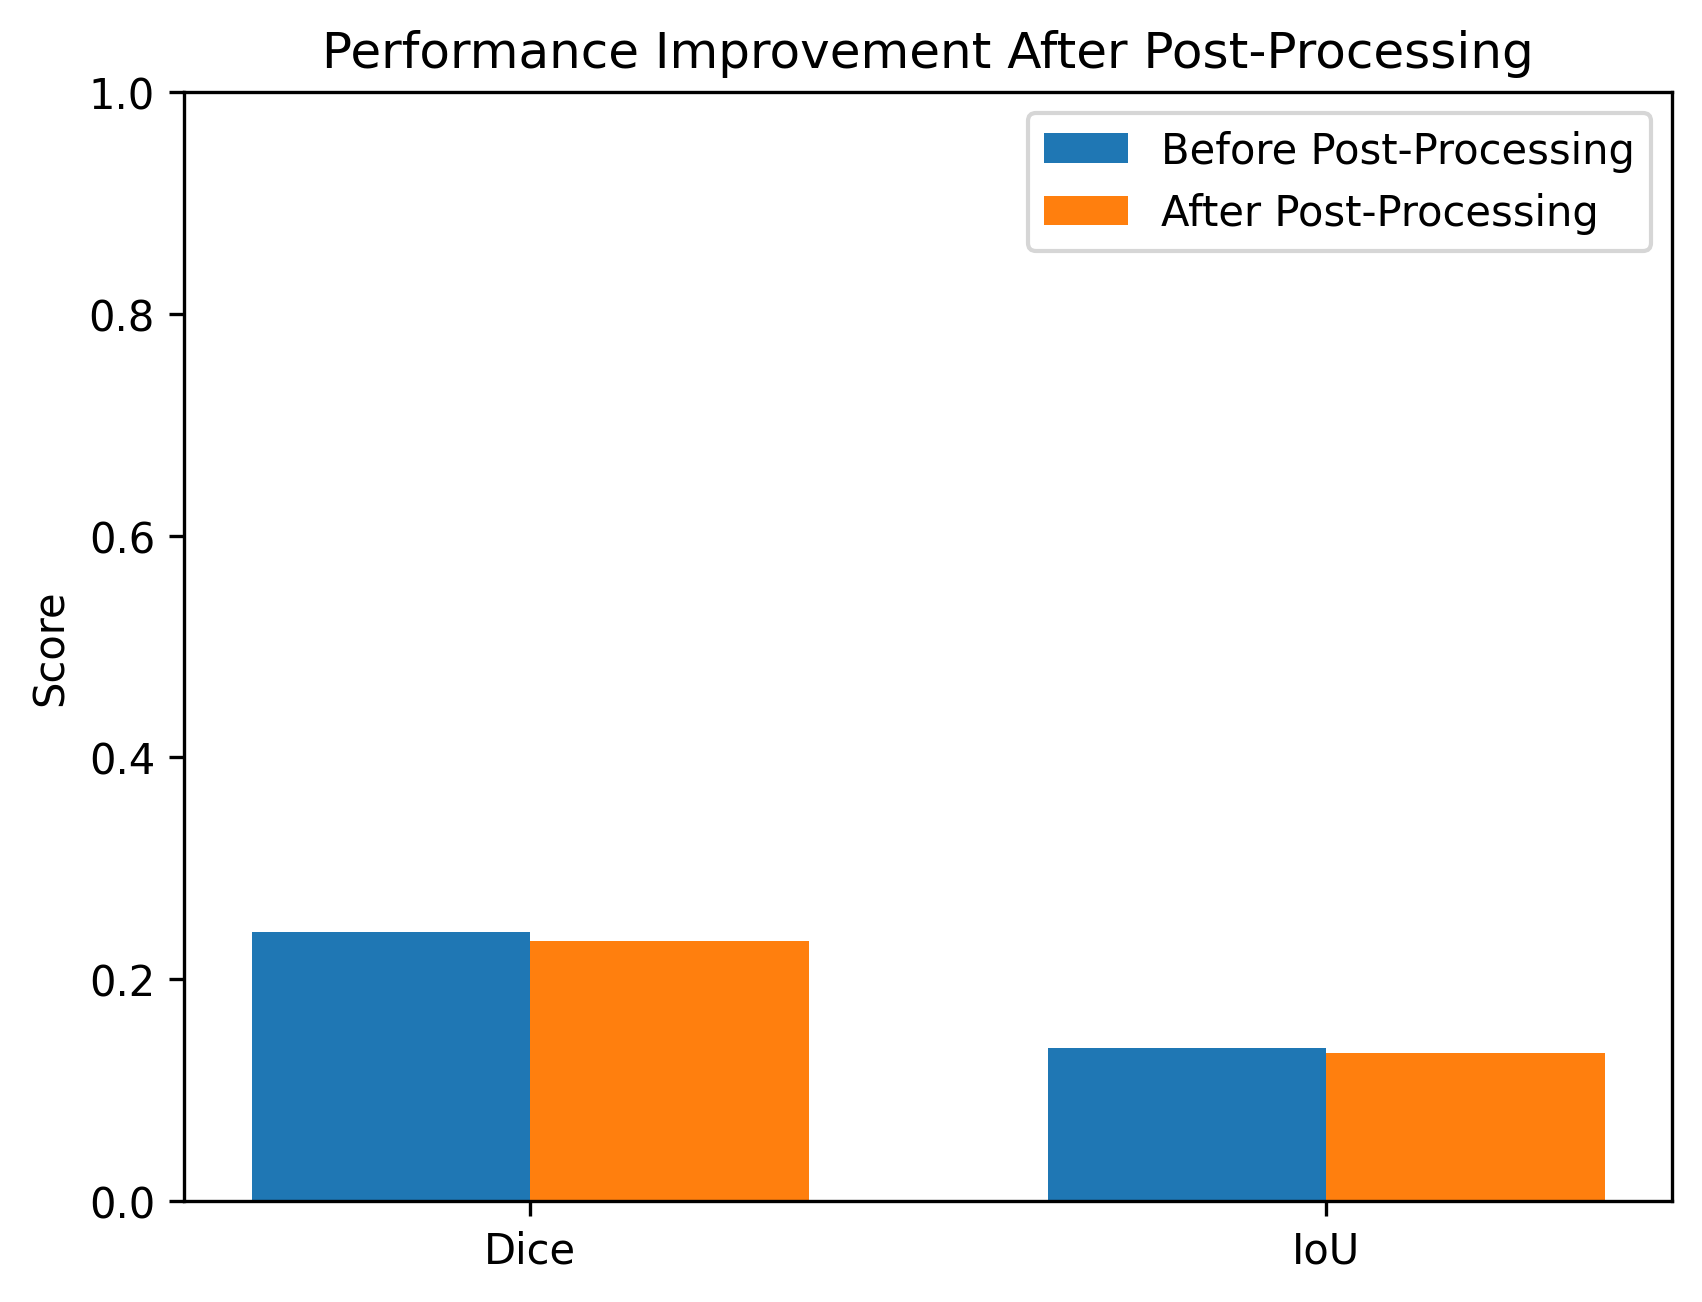

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Compute before post-processing
dice_before = dice_coefficient(Y_val.squeeze(), pred_mask)
iou_before = iou_score(Y_val.squeeze(), pred_mask)

# Compute after post-processing
dice_after = dice_coefficient(Y_val.squeeze(), pred_mask_final)
iou_after = iou_score(Y_val.squeeze(), pred_mask_final)

before = [dice_before, iou_before]
after = [dice_after, iou_after]

labels = ['Dice', 'IoU']
x = np.arange(len(labels))
width = 0.35

plt.figure(dpi=300)

plt.bar(x - width/2, before, width, label='Before Post-Processing')
plt.bar(x + width/2, after, width, label='After Post-Processing')

plt.ylim(0, 1)
plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Performance Improvement After Post-Processing')
plt.legend()

plt.savefig("comparison_graph.png", dpi=300, bbox_inches='tight')
plt.show()